# From raw strain to the GW150914 chirp: a closer look at the preprocessing

Gravitational-wave detectors record a continuous strain time series, but a real signal like GW150914 is buried in noise and invisible by eye until it has been processed. Here we build up that **preprocessing** from the basic tools, one step at a time:

1. fetch 32 seconds of H1 (Hanford) and L1 (Livingston) data around GW150914,
2. look at the raw data and see that the signal is invisible,
3. recall the **Fourier transform**, and what it means for sampled data,
4. estimate the **noise power spectral density** (PSD) with Welch's method, and see why a single periodogram is not enough,
5. **whiten** the data step by step, which makes the chirp appear,
6. compare the two detectors, and work out the delay between them yourself, before seeing the answer, and
7. see that the whole pipeline can be reproduced in a couple of lines with GWpy's own methods.

## Setup

The imports: `gwosc`/`gwpy` to fetch the data, and `numpy`/`scipy`/`matplotlib` for everything that follows.

In [5]:
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")   # a harmless warning from LAL

import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import numpy as np
import scipy.interpolate

from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

## 1. Fetching the GW150914 strain

`gwosc.datasets.event_gps` looks up the event's GPS time, and GWpy's `TimeSeries.fetch_open_data` downloads the strain directly from GWOSC for a detector and a GPS interval — replacing the raw HTTP requests and manual HDF5 parsing of the from-scratch version with two calls. We immediately extract plain NumPy arrays from the result with `.value` and `.times.value`, so that every cell from here on works exactly as if we had downloaded and parsed the file ourselves.

In [6]:
tevent = event_gps("GW150914")
segment = (int(tevent) - 16, int(tevent) + 16)

h1_ts = TimeSeries.fetch_open_data("H1", *segment, sample_rate=4096, cache=True, verbose=True)
l1_ts = TimeSeries.fetch_open_data("L1", *segment, sample_rate=4096, cache=True, verbose=True)

gpstime = h1_ts.times.value
h1strain = h1_ts.value
l1strain = l1_ts.value
t = gpstime - tevent      # time relative to the event (s)

print(f"{len(h1strain)} samples, from GPS {gpstime[0]:.0f} to {gpstime[-1]:.3f} "
      f"({gpstime[-1] - gpstime[0]:.1f} s)")
print(f"event at GPS {tevent}")

Fetched 1 URLs from gwosc.org for [1126259446 .. 1126259478))
Reading data... [Done]
Fetched 1 URLs from gwosc.org for [1126259446 .. 1126259478))
Reading data... [Done]
131072 samples, from GPS 1126259446 to 1126259478.000 (32.0 s)
event at GPS 1126259462.4


## 2. Looking at the raw data

What we have is a *sampled time series*: the strain $h(t)$ measured at $N$ equally spaced times, $t_n = n\,\Delta t$, with a sampling rate $f_s = 1/\Delta t$. Let's put the basic numbers in variables that we will use throughout.

In [7]:
fs = 4096                    # sampling rate (Hz)
dt = 1 / fs                  # time between samples (s)
N = len(h1strain)            # number of samples
duration = N * dt            # total duration (s)

print(f"N = {N} samples, dt = {dt * 1e3:.4f} ms, duration = {duration:.0f} s")

N = 131072 samples, dt = 0.2441 ms, duration = 32 s


The raw H1 strain, with the time of the event marked in orange. The signal is not visible by eye: the strain is dominated by noise of a few $10^{-19}$, while GW150914 has an amplitude of only about $10^{-21}$. It is buried in the noise at the orange line.

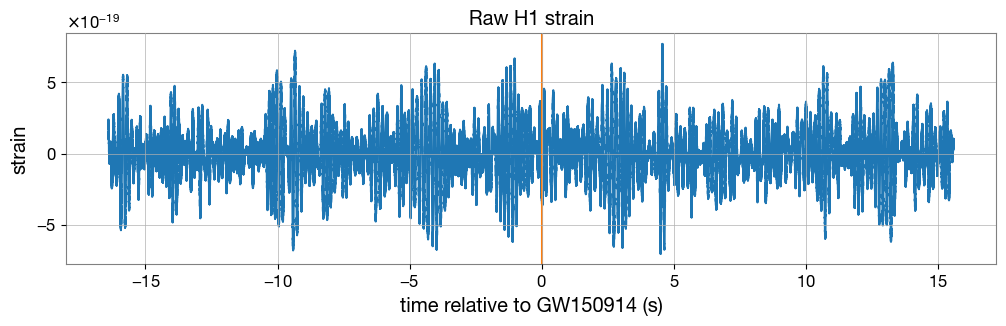

In [8]:

h1strain = h1_ts.value
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, h1strain)
ax.axvline(0, c="C1")
ax.set_xlabel("time relative to GW150914 (s)")
ax.set_ylabel("strain")
ax.set_title("Raw H1 strain")
plt.show()

## 3. The Fourier transform

The noise of a gravitational-wave detector is best described in the **frequency domain**, so the Fourier transform is our main tool. For $N$ samples $x_n$ the discrete Fourier transform (DFT) is

$$\tilde x_k = \sum_{n=0}^{N-1} x_n\, e^{-2\pi i\, k n / N}, \qquad k = 0, 1, \dots, N-1,$$

and $\tilde x_k$ is the amplitude of the oscillation at frequency $f_k = k/(N\,\Delta t)$. Three facts about the discrete transform are worth remembering:

- **Frequency resolution.** The spacing between frequencies is $\Delta f = 1/T$, with $T = N\,\Delta t$ the total duration. To resolve two frequencies that are 0.25 Hz apart we need at least 4 seconds of data.
- **Nyquist frequency.** The highest frequency that can be represented is $f_{\rm Ny} = f_s/2$. At 4096 Hz sampling this is 2048 Hz.
- **Real data.** For a real signal the values at negative frequencies are just the complex conjugates of the positive ones, so we only keep the non-negative half. `np.fft.rfft` does this, and `np.fft.rfftfreq` gives the corresponding frequencies. `np.fft.irfft` transforms back, and the round trip loses nothing.

A toy example: two sinusoids, at 50 Hz (amplitude 1) and 120 Hz (amplitude 0.5), buried in white noise of the same size as the weaker one.

4096 samples -> 2049 frequency bins, spacing 1.00 Hz, highest frequency 2048 Hz
inverse transform recovers the data: True


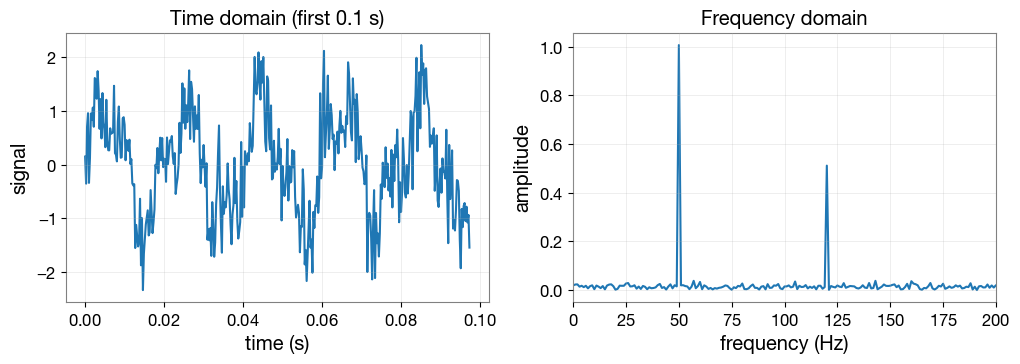

In [9]:
rng = np.random.default_rng(42)

fs_toy = 4096                                    # same sampling rate as the real data
t_toy = np.arange(0, 1.0, 1 / fs_toy)            # one second of data
x_toy = (1.0 * np.sin(2 * np.pi * 50 * t_toy)
         + 0.5 * np.sin(2 * np.pi * 120 * t_toy)
         + 0.5 * rng.normal(size=t_toy.size))

x_toy_fft = np.fft.rfft(x_toy)                              # transform (non-negative frequencies)
f_toy = np.fft.rfftfreq(x_toy.size, d=1 / fs_toy)           # frequency of each bin

print(f"{x_toy.size} samples -> {x_toy_fft.size} frequency bins, "
      f"spacing {f_toy[1]:.2f} Hz, highest frequency {f_toy[-1]:.0f} Hz")
print("inverse transform recovers the data:",
      np.allclose(np.fft.irfft(x_toy_fft, n=x_toy.size), x_toy))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(t_toy[:400], x_toy[:400])
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("signal")
axes[0].set_title("Time domain (first 0.1 s)")

axes[1].plot(f_toy, 2 * np.abs(x_toy_fft) / x_toy.size)       # 2|x_k|/N = amplitude of a sinusoid
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("frequency (Hz)")
axes[1].set_ylabel("amplitude")
axes[1].set_title("Frequency domain")
for ax in axes:
    ax.grid(alpha=0.3)
plt.show()

In the time domain the two sinusoids are hard to see, but in the frequency domain they stand out as two clean peaks, with the heights we put in (1 and 0.5; the factor $2/N$ converts $|\tilde x_k|$ into the amplitude of a sinusoid). The noise is spread thinly over all frequencies.

This is the basic tool we need: turning a time series into a frequency-domain picture. Real detector noise looks nothing like two clean tones, so next we use the same transform to characterise it statistically — the noise **power spectral density**.

## 4. Estimating the noise spectrum

### 4.1 The periodogram

The **power spectral density** (PSD) $S(f)$ tells us how much noise power there is per unit frequency. The simplest estimate is the *periodogram*: the squared magnitude of the Fourier transform, normalised so that its integral over frequency gives back the variance of the data (Parseval's theorem):

$$\hat S(f_k) = \frac{2\,\Delta t}{N}\,|\tilde x_k|^2.$$

The factor 2 accounts for keeping only the positive frequencies (a "one-sided" PSD). Its square root, $\sqrt{S(f)}$, is the **amplitude spectral density** (ASD), with units of $1/\sqrt{\rm Hz}$ for strain data.

We don't need to code this formula by hand: `mlab.psd` computes it for us. Calling it with `NFFT` equal to the full length of the data treats the 32 s as a single segment, which is exactly the periodogram above.

65537 frequency bins with spacing 0.03125 Hz (= 1/32 s)


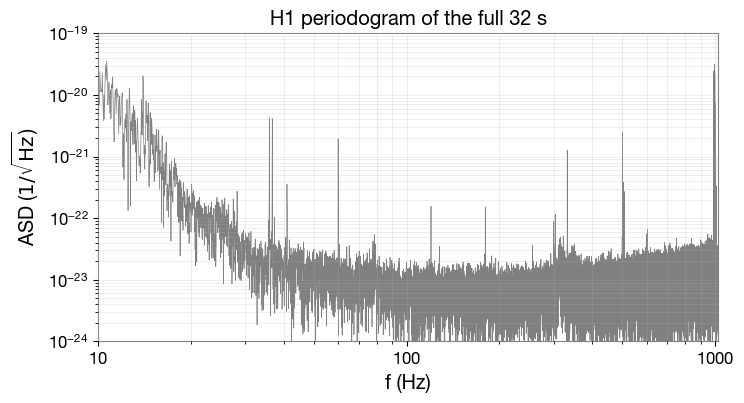

In [10]:
psd_single, f_single = mlab.psd(h1strain, NFFT=N, Fs=fs)

print(f"{len(f_single)} frequency bins with spacing {f_single[1]:.5f} Hz (= 1/{duration:.0f} s)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(f_single, np.sqrt(psd_single), color="0.5", lw=0.5)
ax.set_xlabel("f (Hz)")
ax.set_ylabel(r"ASD ($1/\sqrt{\rm Hz}$)")
ax.set_title("H1 periodogram of the full 32 s")
ax.set_xlim(10, 1024)
ax.set_ylim(1e-24, 1e-19)
ax.grid(alpha=0.3, which="both")
plt.show()

The overall shape is clear, but the curve is very noisy: it fluctuates up and down from one frequency bin to the next. This is not a defect of the data. For Gaussian noise every periodogram value is a random number with a broad (exponential) distribution, whose scatter is as large as its mean: a 100% error, and it does *not* get better by taking a longer stretch of data, because a longer stretch only gives more, equally noisy, frequency bins.

### 4.2 Welch's method

The remedy is **Welch's method**: cut the data into segments, compute the periodogram of each (again with `mlab.psd`), and **average** them. Averaging $K$ independent periodograms reduces the scatter by $\sqrt{K}$. In exchange, each segment is shorter than the full data, so the frequency resolution is worse, $\Delta f = 1/T_{\rm seg}$.

We use segments of 4 s (`NFFT = 4 * fs` samples), with the default of **no overlap** between segments, so our 32 s give $32/4 = 8$ segments, and the resolution is $1/4\,{\rm s} = 0.25$ Hz. (Other implementations, like `scipy.signal.welch`, use 50% overlapping segments by default, which extracts a little more information from the same data.)

8 segments of 4 s -> resolution 0.25 Hz


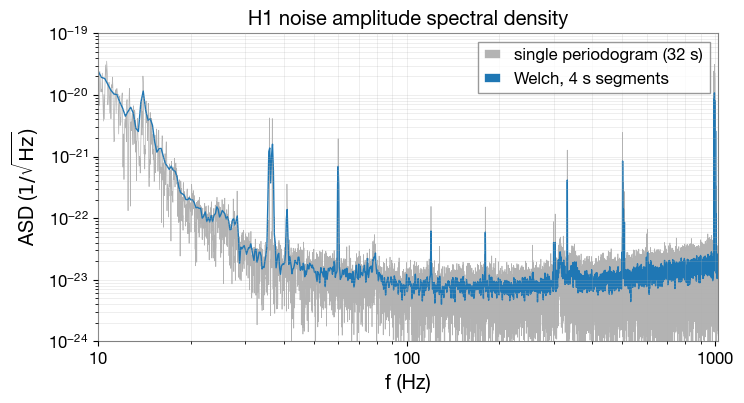

In [11]:
nfft = 4 * fs
psd, freqs = mlab.psd(h1strain, NFFT=nfft, Fs=fs)

print(f"{N // nfft} segments of {nfft / fs:.0f} s -> resolution {freqs[1]:.2f} Hz")

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(f_single, np.sqrt(psd_single), color="0.7", lw=0.5, label="single periodogram (32 s)")
ax.loglog(freqs, np.sqrt(psd), color="C0", lw=1, label="Welch, 4 s segments")
ax.set_xlabel("f (Hz)")
ax.set_ylabel(r"ASD ($1/\sqrt{\rm Hz}$)")
ax.set_title("H1 noise amplitude spectral density")
ax.set_xlim(10, 1024)
ax.set_ylim(1e-24, 1e-19)
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

The averaged curve is much smoother, and follows the middle of the noisy one. Let's read it:

The noise is far from white: at 10 Hz it is about three orders of magnitude larger than around 100–300 Hz, where the detector is most sensitive (this low-frequency part is seismic and other environmental noise). On top of the smooth curve there are narrow spikes: instrumental lines such as the 60 Hz power-line frequency and its harmonics, and the violin modes of the mirror suspensions near 500 Hz.

The raw time series above is dominated by this low-frequency noise, which hides the much weaker signal (GW150914 sweeps through roughly 35–250 Hz).

### 4.3 Segment length: a trade-off

Short segments give many averages (a smooth curve) but poor resolution: the narrow instrumental lines are smeared out. Long segments resolve the lines but give few averages (a noisy curve). Here is the 30–90 Hz region, which contains a few lines, for three choices:

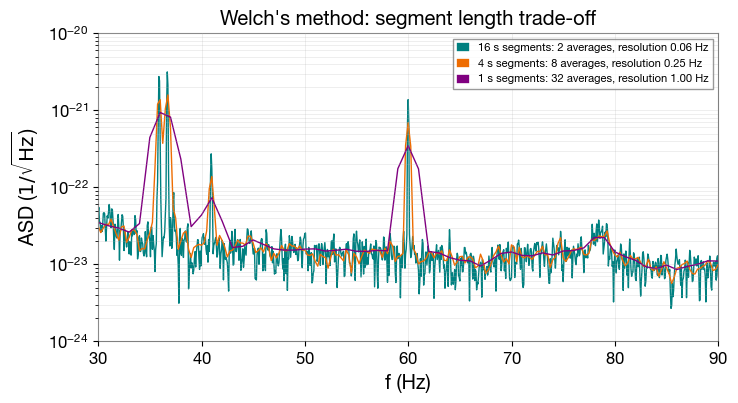

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for seconds, color in [(16, "teal"), (4, "#ee6c01"), (1, "purple")]:
    n_seg = seconds * fs
    p, f = mlab.psd(h1strain, NFFT=n_seg, Fs=fs)
    ax.semilogy(f, np.sqrt(p), color=color, lw=1,
                label=f"{seconds} s segments: {N // n_seg} averages, resolution {1 / seconds:.2f} Hz")
ax.set_xlim(30, 90)
ax.set_ylim(1e-24, 1e-20)
ax.set_xlabel("f (Hz)")
ax.set_ylabel(r"ASD ($1/\sqrt{\rm Hz}$)")
ax.set_title("Welch's method: segment length trade-off")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.show()

We stay with 4 s segments, a common choice for this kind of analysis.

### 4.4 The PSD is estimated from data that contains the signal

One more point about the way we use the PSD. We estimate it from the same 32 s that we later whiten, and this stretch *contains GW150914*. Is that a problem? Let's check. We compute the average noise power in the signal band (35–250 Hz) for each of the eight segments separately, and compare it to the median of the eight. The event lies in the segment that is marked.

In [13]:
seg_len = nfft
band = (freqs >= 35) & (freqs <= 250)

seg_power = np.array([mlab.psd(h1strain[k * seg_len:(k + 1) * seg_len], NFFT=seg_len, Fs=fs)[0][band].mean()
                      for k in range(N // seg_len)])
event_segment = int((tevent - gpstime[0]) * fs) // seg_len

print("band power of each 4 s segment / median over the segments:")
for k, ratio in enumerate(seg_power / np.median(seg_power)):
    print(f"  segment {k}: {ratio:.3f}" + ("   <-- contains GW150914" if k == event_segment else ""))

band power of each 4 s segment / median over the segments:
  segment 0: 1.028
  segment 1: 0.981
  segment 2: 0.964
  segment 3: 1.006
  segment 4: 0.976   <-- contains GW150914
  segment 5: 1.018
  segment 6: 1.002
  segment 7: 0.998


The segment with the event is not distinguishable from the others: their band power differs by about the same small amount as the segments differ among themselves. The reason is that GW150914 is short (a fraction of a second) and the noise is much louder than the signal at every single frequency, so the eight-segment average is essentially the noise PSD.

For a long signal (a binary neutron star spends minutes in the band) or a very loud one, this would not be safe, and the standard practice is to estimate the PSD from **off-source** data around the event, or to use a median instead of a mean for the average, which is insensitive to a single loud segment.

## 5. Whitening the data

Why do we whiten? For stationary noise, the Fourier components at different frequencies are (approximately) independent random numbers, with a variance proportional to the PSD, $\langle |\tilde n_k|^2 \rangle \propto S(f_k)$. So the noise is *not* the same size at every frequency. **Whitening** divides each component by $\sqrt{S(f_k)}$, which gives all frequencies the same noise variance, i.e. it turns the coloured noise into white noise:

$$\tilde x^{\rm white}_k = \frac{\tilde x_k}{\sqrt{S(f_k)}}.$$

A signal buried in white noise is easier to recognise by eye, and every frequency now counts in proportion to its signal-to-noise ratio. (This is also the weighting that a matched-filter search applies.)

We do it in four steps; the frequency band that we keep is chosen in step 2.

**Step 1: transform.** We take the real FFT of the strain.

In [14]:
bandpass = (20, 350)                   # Hz: the band we keep

h1_fft = np.fft.rfft(h1strain)
fft_freqs = np.fft.rfftfreq(N, dt)

**Step 2: the PSD, and the band.** We use the Welch PSD from section 4 (`psd`, on the frequencies `freqs`). To keep only the frequencies from 20 to 350 Hz we set the PSD to its **maximum value** outside of that band. Dividing by such a huge number makes those components negligible: they are effectively removed. (The band is where GW150914 has its power. Below 20 Hz the noise is dominated by seismic disturbances and above 350 Hz there is little signal.)

In [15]:
psd_used = psd.copy()
psd_used[(freqs < bandpass[0]) | (freqs > bandpass[1])] = np.max(psd)

**Step 3: interpolate.** The Welch PSD has a frequency resolution of 0.25 Hz, but the FFT of the full 32 s has a spacing of $1/32$ Hz, eight times finer. We interpolate the PSD onto the FFT frequencies.

In [16]:
psd_fft = scipy.interpolate.interp1d(freqs, psd_used)(fft_freqs)

**Step 4: divide, and transform back.** We divide by $\sqrt{S}$ and use the inverse FFT to return to the time domain. The extra factor $\sqrt{2\,\Delta t}$ is the same normalisation as the periodogram of section 4.1: the PSD of white noise with variance $\sigma^2$ is $S = 2\sigma^2\Delta t$, so dividing by $\sqrt{S}$ and multiplying by $\sqrt{2\Delta t}$ maps it to noise with standard deviation 1, whatever the units of the data were.

In [17]:
h1_white_fft = h1_fft / np.sqrt(psd_fft) * np.sqrt(2 * dt)
h1_white = np.fft.irfft(h1_white_fft, n=N)

Did it work? We estimate the spectrum of the whitened data with Welch's method, next to the one of the raw data. It should be flat inside the band (equal noise at all frequencies) and small outside of it.

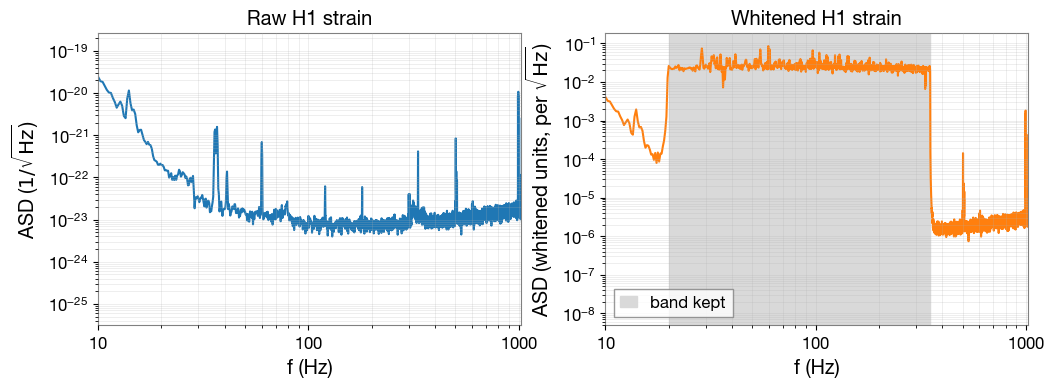

In [18]:
psd_white, _ = mlab.psd(h1_white, NFFT=nfft, Fs=fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
axes[0].loglog(freqs, np.sqrt(psd))
axes[0].set_ylabel(r"ASD ($1/\sqrt{\rm Hz}$)")
axes[0].set_title("Raw H1 strain")

axes[1].loglog(freqs, np.sqrt(psd_white), color="C1")
axes[1].set_ylabel("ASD (whitened units, per $\\sqrt{\\rm Hz}$)")
axes[1].set_title("Whitened H1 strain")
axes[1].axvspan(*bandpass, color="0.85", zorder=0, label="band kept")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("f (Hz)")
    ax.set_xlim(10, 1024)
    ax.grid(alpha=0.3, which="both")
plt.show()

The whitened spectrum is flat between 20 and 350 Hz (apart from small dips at the strongest instrumental lines), and much lower outside of it. The colour of the noise is gone.

We now put the four steps in a function, so that we can apply it to the other detector. As a check of the normalisation, we whiten white noise of very different sizes over the whole band and confirm that we always get noise with a standard deviation of about 1.

In [ ]:
def whiten(strain, sampling=4096, bandpass=(20, 350)):
    n = len(strain)
    dt = 1 / sampling

    # step 1: transform
    strain_fft = np.fft.rfft(strain)
    fft_freqs = np.fft.rfftfreq(n, dt)

    # step 2: PSD (Welch), maxed out outside the bandpass
    psd, psd_freqs = mlab.psd(strain, NFFT=sampling * 4, Fs=sampling)
    psd[(psd_freqs < bandpass[0]) | (psd_freqs > bandpass[1])] = np.max(psd)

    # step 3: interpolate the PSD to the FFT frequencies
    psd_fft = scipy.interpolate.interp1d(psd_freqs, psd)(fft_freqs)

    # step 4: whiten and transform back to the time domain
    return np.fft.irfft(strain_fft / np.sqrt(psd_fft) * np.sqrt(2 * dt), n=n)


print("same result as the step-by-step version:", np.allclose(whiten(h1strain), h1_white))

for sigma in [1.0, 5.0, 1e-20]:
    noise = np.random.default_rng(1).normal(scale=sigma, size=N)
    print(f"white noise with sigma = {sigma:g}: standard deviation after whitening = "
          f"{whiten(noise, bandpass=(0, fs / 2)).std():.2f}")

We whiten H1 and plot the whole 32 seconds. The data are not tapered before the Fourier transform, so the whitened series shows artifacts at the two edges; but what is in the middle?

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, h1_white)
ax.set_xlabel("time relative to GW150914 (s)")
ax.set_ylabel("whitened strain")
ax.set_title("Whitened H1 strain (full 32 s)")
plt.show()

The noise is now roughly stationary and of the same size everywhere, apart from the edge artifacts. Let's zoom in on $\pm 0.1$ s around the event.

In [ ]:
around = (t > -0.1) & (t < 0.1)     # a 0.2 s window centred on the event

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t[around], h1_white[around])
ax.set_xlabel("time relative to GW150914 (s)")
ax.set_ylabel("whitened strain")
ax.set_title("Whitened H1 strain around the event")
plt.show()

There it is: an oscillation whose amplitude and frequency grow over roughly $-0.03$ s to $+0.03$ s, peaking near $+0.025$ s and then quickly dying away. This is the chirp of the merging black holes, and the same signal whose zero crossings we read off in week 1 (there, times were measured from GPS 1126259462, here from the catalog time, 0.4 s later). Even after whitening, a single detector shows only a modest signal on top of the noise.

## 6. The other detector, and the light-travel time

We repeat the same procedure for L1 (LIGO Livingston), in orange.

In [ ]:
l1_white = whiten(l1strain)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t[around], l1_white[around], "C1")
ax.set_xlabel("time relative to GW150914 (s)")
ax.set_ylabel("whitened strain")
ax.set_title("Whitened L1 strain around the event")
plt.show()

The same chirp is present in both detectors, but at slightly different times. The two LIGO sites are about 3000 km apart, so a signal travelling at the speed of light can arrive at one of them up to $\approx 10$ ms before the other.

### Exercise: measure the light-travel-time delay

Find that delay yourself, before reading any further: scan a range of candidate delays, and for each one measure how well the shifted, inverted L1 strain matches H1 around the event. Report the delay that gives the best match, and compare it with the 10 ms maximum light-travel time between the two LIGO sites.

*Hint: `np.corrcoef(a, b)[0, 1]` gives the correlation coefficient between two arrays of the same length. A time shift moves L1's samples off H1's time grid, so interpolate one onto the other first, e.g. with `np.interp`. Once you have a correlation value for each candidate delay, `np.argmax` finds the best one.*

In [ ]:
# TODO: choose a range of candidate delays to scan, in milliseconds, and convert to seconds
# delays_ms = np.arange(..., ..., ...)
# shifts = delays_ms / 1000

# TODO: for each shift, interpolate l1_white onto H1's time grid with np.interp, and
# correlate the result with -h1_white using np.corrcoef
# correlations = []
# for shift in shifts:
#     l1_shifted = np.interp(..., ..., ...)
#     correlations.append(np.corrcoef(..., ...)[0, 1])
# correlations = np.array(correlations)

# TODO: find the delay that maximises the correlation, with np.argmax
# best_delay = ...

print(f"best delay: {best_delay:.1f} ms (correlation {correlations.max():.2f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(delays_ms, correlations, "o-")
ax.axvline(best_delay, color="C1", ls="--", label=f"best: {best_delay:.1f} ms")
ax.set_xlabel("candidate delay (ms)")
ax.set_ylabel("correlation with H1")
ax.legend()
plt.show()

As it turns out, a shift of about 7 ms lines the two up, with L1 seeing the signal first. We shift L1 by $+7$ ms and flip its sign — the two detectors are oriented differently, so they respond with opposite sign to the same wave — and overlay the result:

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t[around], h1_white[around], label="H1")
ax.plot(t[around] + 0.007, -l1_white[around], label="L1 (shifted by 7 ms, inverted)")
ax.set_xlabel("time relative to GW150914 (s)")
ax.set_ylabel("whitened strain")
ax.set_title("H1 and L1 overlaid")
ax.legend()
plt.show()

After this the main features of the two curves line up, especially in the loud part between about 0.01 s and 0.03 s. The remaining differences are due to noise, and to the detectors' different sensitivities.

The delay being less than the light-travel time between the sites is the expected signature of a signal that propagates at the speed of light; in a real analysis it is also one of the ingredients used to localise the source on the sky.

## 7. The GWpy shortcut

Everything above — the periodogram, Welch's method, the four whitening steps — is exactly what GWpy's own methods do internally. Now that we understand what is inside them, we can use them directly: two method calls reproduce the whitened H1 strain we just built by hand.

In [ ]:
h1_gwpy_white = h1_ts.whiten(4, 2).bandpass(*bandpass)
around_gwpy = h1_gwpy_white.crop(tevent - 0.1, tevent + 0.1)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(around_gwpy.times.value - tevent, around_gwpy.value)
ax.set_xlabel("time relative to GW150914 (s)")
ax.set_ylabel("whitened strain")
ax.set_title("Whitened H1 strain around the event (GWpy)")
plt.show()

The same chirp as the H1 plot in section 5, produced with the two GWpy methods that wrap everything we just did by hand. `lecture_2_strain_gwpy.ipynb` takes this further, fetching and processing both detectors with GWpy end to end.

## 8. What we have learned

- The discrete Fourier transform has a frequency resolution $1/T$ and a maximum frequency $f_s/2$.
- A single periodogram is a very noisy estimate of the PSD. **Welch's method** averages the periodograms of several segments, trading frequency resolution for a smoother estimate.
- **Whitening** divides the Fourier transform by the square root of the PSD, so that every frequency has the same noise level. Together with a band-pass, it makes the GW150914 chirp visible in both detectors.
- Even though the PSD is estimated from the same stretch of data that contains GW150914, the event is too short and too quiet to bias the eight-segment average.
- The signal arrives at H1 and L1 with a relative delay of about 7 ms, less than the 10 ms light-travel time between the sites.

### Things to try (if you wish)

1. **Change the segment length of the PSD.** In `whiten`, replace `sampling * 4` by `sampling * 1` or `sampling * 16`. How does the whitened data around the event change?
2. **Change the bandpass** (say to `(30, 250)` or `(10, 500)`) and re-plot the zoomed-in H1 strain. How does the chirp look? What happens if you use `(0, 2048)`?
3. **Use off-source data for the PSD.** Estimate the PSD from the first 12 s of the data only, which do not contain the event, and use it in the whitening. Is the result different?
4. **Try another event.** Change the event name in section 1 to another GWTC-1 event, for example `GW170104`. The 7 ms shift and the $\pm 0.1$ s zoom window are tuned to GW150914, so adjust them. The signal-to-noise ratio of GW170104 is about half that of GW150914 (see the catalog): can you still see the chirp by eye?